# 05 — M6 Feature Localization Score (Moran's I)

Validates and explores the M6 spatial coherence metric on the DINOv2 BatchTopK SAE.

- **Synthetic tests**: verify Moran's I on known patterns (clustered, checkerboard, random)
- **Real SAE run**: compute M6 on val shards
- **Distribution analysis**: histogram + CDF of per-feature scores
- **Spatial map visualisation**: heatmaps of the most/least coherent features

In [1]:
# ── Cell 1: Imports and setup ────────────────────────────────────────────────
import glob
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.evaluation.spatial_coherence.localization import (
    FeatureLocalizationScore,
    _build_weight_matrix,
    _compute_morans_i_batch,
)
from src.utils.paths import CHECKPOINT_ROOT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ENCODE_BATCH_SIZE = 512
print(f"Device: {DEVICE}")

Device: cuda


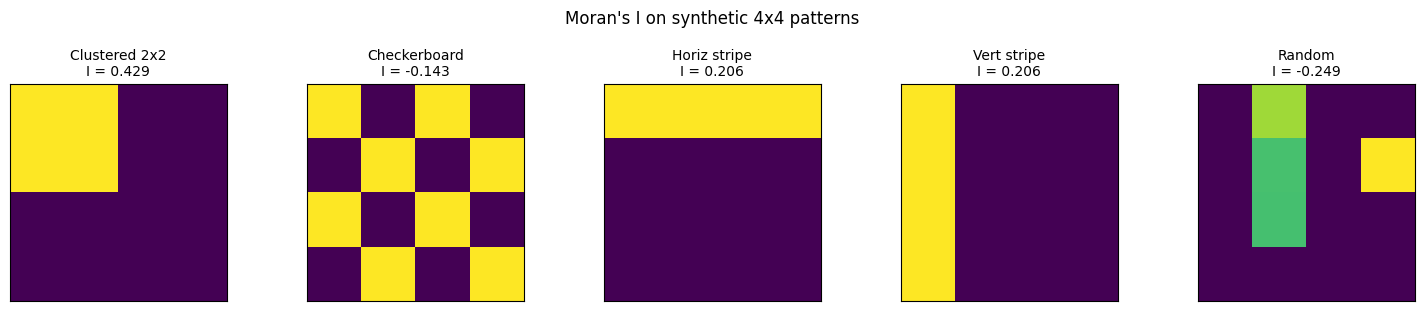

Expected: clustered/stripes > 0, checkerboard < 0, random near 0


In [2]:
# ── Cell 2: Synthetic pattern tests ──────────────────────────────────────────
W4 = _build_weight_matrix(4, 4)
N4, S4 = 16, float(W4.sum())

patterns = {}

# Clustered: 2x2 block in top-left
c = torch.zeros(1, 16, 1)
for r in range(2):
    for col in range(2):
        c[0, r * 4 + col, 0] = 1.0
mi, _ = _compute_morans_i_batch(c, W4, N4, S4, 1)
patterns["Clustered 2x2"] = (c[0, :, 0].reshape(4, 4).numpy(), float(mi[0, 0]))

# Checkerboard
c = torch.zeros(1, 16, 1)
for r in range(4):
    for col in range(4):
        c[0, r * 4 + col, 0] = 1.0 if (r + col) % 2 == 0 else 0.0
mi, _ = _compute_morans_i_batch(c, W4, N4, S4, 1)
patterns["Checkerboard"] = (c[0, :, 0].reshape(4, 4).numpy(), float(mi[0, 0]))

# Horizontal stripe
c = torch.zeros(1, 16, 1)
for col in range(4):
    c[0, col, 0] = 1.0
mi, _ = _compute_morans_i_batch(c, W4, N4, S4, 1)
patterns["Horiz stripe"] = (c[0, :, 0].reshape(4, 4).numpy(), float(mi[0, 0]))

# Vertical stripe
c = torch.zeros(1, 16, 1)
for r in range(4):
    c[0, r * 4, 0] = 1.0
mi, _ = _compute_morans_i_batch(c, W4, N4, S4, 1)
patterns["Vert stripe"] = (c[0, :, 0].reshape(4, 4).numpy(), float(mi[0, 0]))

# Random sparse
torch.manual_seed(0)
c = torch.rand(1, 16, 1); c[c < 0.6] = 0.0
mi, _ = _compute_morans_i_batch(c, W4, N4, S4, 1)
patterns["Random"] = (c[0, :, 0].reshape(4, 4).numpy(), float(mi[0, 0]))

fig, axes = plt.subplots(1, len(patterns), figsize=(3 * len(patterns), 3))
for ax, (name, (grid, mi_val)) in zip(axes, patterns.items()):
    ax.imshow(grid, cmap="viridis", vmin=0)
    ax.set_title(f"{name}\nI = {mi_val:.3f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Moran's I on synthetic 4x4 patterns", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Expected: clustered/stripes > 0, checkerboard < 0, random near 0")

In [3]:
# ── Cell 3: Load SAE and val stats ───────────────────────────────────────────
CHECKPOINT_DIR = os.path.join(CHECKPOINT_ROOT, "dinov2_vitb14", "batchtopk_16x_k192")
VAL_DIR = "/mnt/NAS/data/ds5725/visaebench/activations_val/dinov2_vitb14/layer_11"

with open(os.path.join(CHECKPOINT_DIR, "config.yaml")) as f:
    cfg = yaml.safe_load(f)
d_model, dict_size = cfg["d_model"], cfg["d_model"] * cfg["expansion_factor"]
k, arch = cfg["k"], cfg["architecture"]
print(f"SAE: {arch}  d_model={d_model}  dict_size={dict_size}  k={k}")

from overcomplete import BatchTopKSAE, TopKSAE
if arch == "batchtopk":
    sae = BatchTopKSAE(input_shape=d_model, nb_concepts=dict_size,
                       top_k=k * ENCODE_BATCH_SIZE, device=DEVICE)
else:
    sae = TopKSAE(input_shape=d_model, nb_concepts=dict_size, top_k=k, device=DEVICE)

sd = torch.load(os.path.join(CHECKPOINT_DIR, "sae.pt"), map_location=DEVICE, weights_only=True)
saved_thr = sd.pop("_running_threshold", None)
sae.load_state_dict(sd)
if arch == "batchtopk":
    if saved_thr is not None:
        sae.running_threshold = saved_thr.to(DEVICE)
    else:
        sae.train()
        with torch.no_grad():
            sae(torch.randn(ENCODE_BATCH_SIZE, d_model, device=DEVICE))
sae.eval()
print("SAE loaded.")

with open(os.path.join(VAL_DIR, "stats.json")) as f:
    stats = json.load(f)
mean = torch.tensor(stats["mean"], dtype=torch.float32)
std = float(stats["std"])
shard_paths = sorted(glob.glob(os.path.join(VAL_DIR, "shard_*.pt")))
print(f"{len(shard_paths)} val shards")

SAE: batchtopk  d_model=768  dict_size=12288  k=192
SAE loaded.
10 val shards


In [11]:
# ── Cell 4: Run M6 (first 2 shards for quick test) ──────────────────────────
# Change to shard_paths for the full 50K-image run (~5 min)
TEST_SHARDS = shard_paths

metric = FeatureLocalizationScore(
    grid_h=16, grid_w=16,        # DINOv2 = 16x16 patches
    min_active_patches=5,
    min_valid_images=10,          # use 50 for full run
    encode_batch_size=ENCODE_BATCH_SIZE,
    batch_size_images=64,
)
results = metric.evaluate(
    sae=sae, shard_paths=TEST_SHARDS, mean=mean, std=std,
    device=DEVICE, dict_size=dict_size,
)

r = results["results"]
print("M6 Results")
print("=" * 40)
for key in ["mean_morans_i", "median_morans_i", "std_morans_i",
            "percentile_25", "percentile_75"]:
    v = r[key]
    print(f"  {key:.<30s} {v:.4f}" if v is not None else f"  {key:.<30s} N/A")
print(f"  Evaluable: {r['num_evaluable_features']} / {r['num_total_features']} ({r['frac_evaluable']:.1%})")

M6 localization:   0%|          | 0/10 [00:00<?, ?it/s]

M6 localization: 100%|██████████| 10/10 [05:28<00:00, 32.87s/it]

M6 Results
  mean_morans_i................. 0.2387
  median_morans_i............... 0.2272
  std_morans_i.................. 0.0820
  percentile_25................. 0.1858
  percentile_75................. 0.2799
  Evaluable: 10499 / 12288 (85.4%)


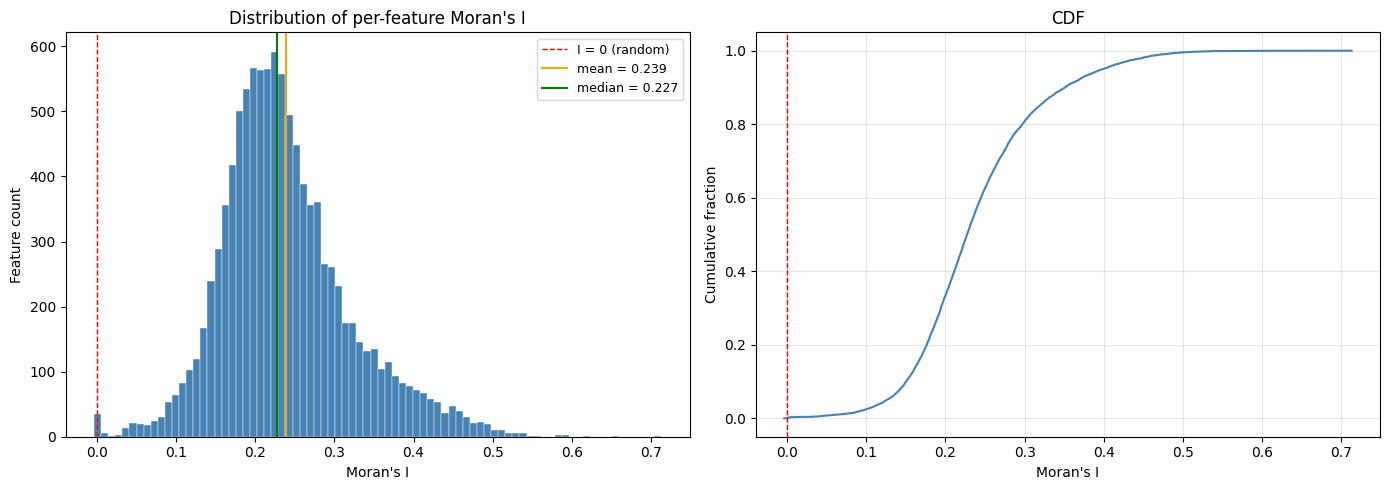

I > 0 (spatially coherent):  99.9%
I > 0.2 (strongly coherent): 66.6%
I < 0 (dispersed):           0.1%
Expected I under null:       -0.0039


In [13]:
# ── Cell 5: Distribution plots ──────────────────────────────────────────────
scores = np.array([s if s is not None else np.nan for s in r["per_feature_scores"]])
valid_scores = scores[~np.isnan(scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(valid_scores, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", ls="--", lw=1, label="I = 0 (random)")
ax.axvline(np.mean(valid_scores), color="orange", lw=1.5,
           label=f"mean = {np.mean(valid_scores):.3f}")
ax.axvline(np.median(valid_scores), color="green", lw=1.5,
           label=f"median = {np.median(valid_scores):.3f}")
ax.set_xlabel("Moran's I"); ax.set_ylabel("Feature count")
ax.set_title("Distribution of per-feature Moran's I")
ax.legend(fontsize=9)

# CDF
ax = axes[1]
ax.plot(np.sort(valid_scores), np.linspace(0, 1, len(valid_scores)),
        color="steelblue", lw=1.5)
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("Moran's I"); ax.set_ylabel("Cumulative fraction")
ax.set_title("CDF"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"I > 0 (spatially coherent):  {(valid_scores > 0).mean():.1%}")
print(f"I > 0.2 (strongly coherent): {(valid_scores > 0.2).mean():.1%}")
print(f"I < 0 (dispersed):           {(valid_scores < 0).mean():.1%}")
print(f"Expected I under null:       {-1/(256-1):.4f}")

In [14]:
# ── Cell 6: Encode a few images for visualisation ────────────────────────────
shard = torch.load(shard_paths[0], map_location="cpu", weights_only=True)
IMG_INDICES = [0, 100, 500, 1000]

scores_arr = np.array([s if s is not None else np.nan for s in r["per_feature_scores"]])
ranked = np.argsort(np.nan_to_num(scores_arr, nan=-999))
top_feats = ranked[-5:][::-1]
bottom_feats = [f for f in ranked if not np.isnan(scores_arr[f])][:5]

def encode_image(sae, patches, mean, std, device, bs=512):
    tokens = (patches.float() - mean) / std
    codes = []
    with torch.no_grad():
        for s in range(0, tokens.shape[0], bs):
            _, c, _ = sae(tokens[s:s+bs].to(device))
            codes.append(c.cpu())
    return torch.cat(codes, dim=0)

encoded = {i: encode_image(sae, shard[i], mean, std, DEVICE) for i in IMG_INDICES}
print(f"Encoded {len(encoded)} images, codes shape: {encoded[0].shape}")

Encoded 4 images, codes shape: torch.Size([256, 12288])


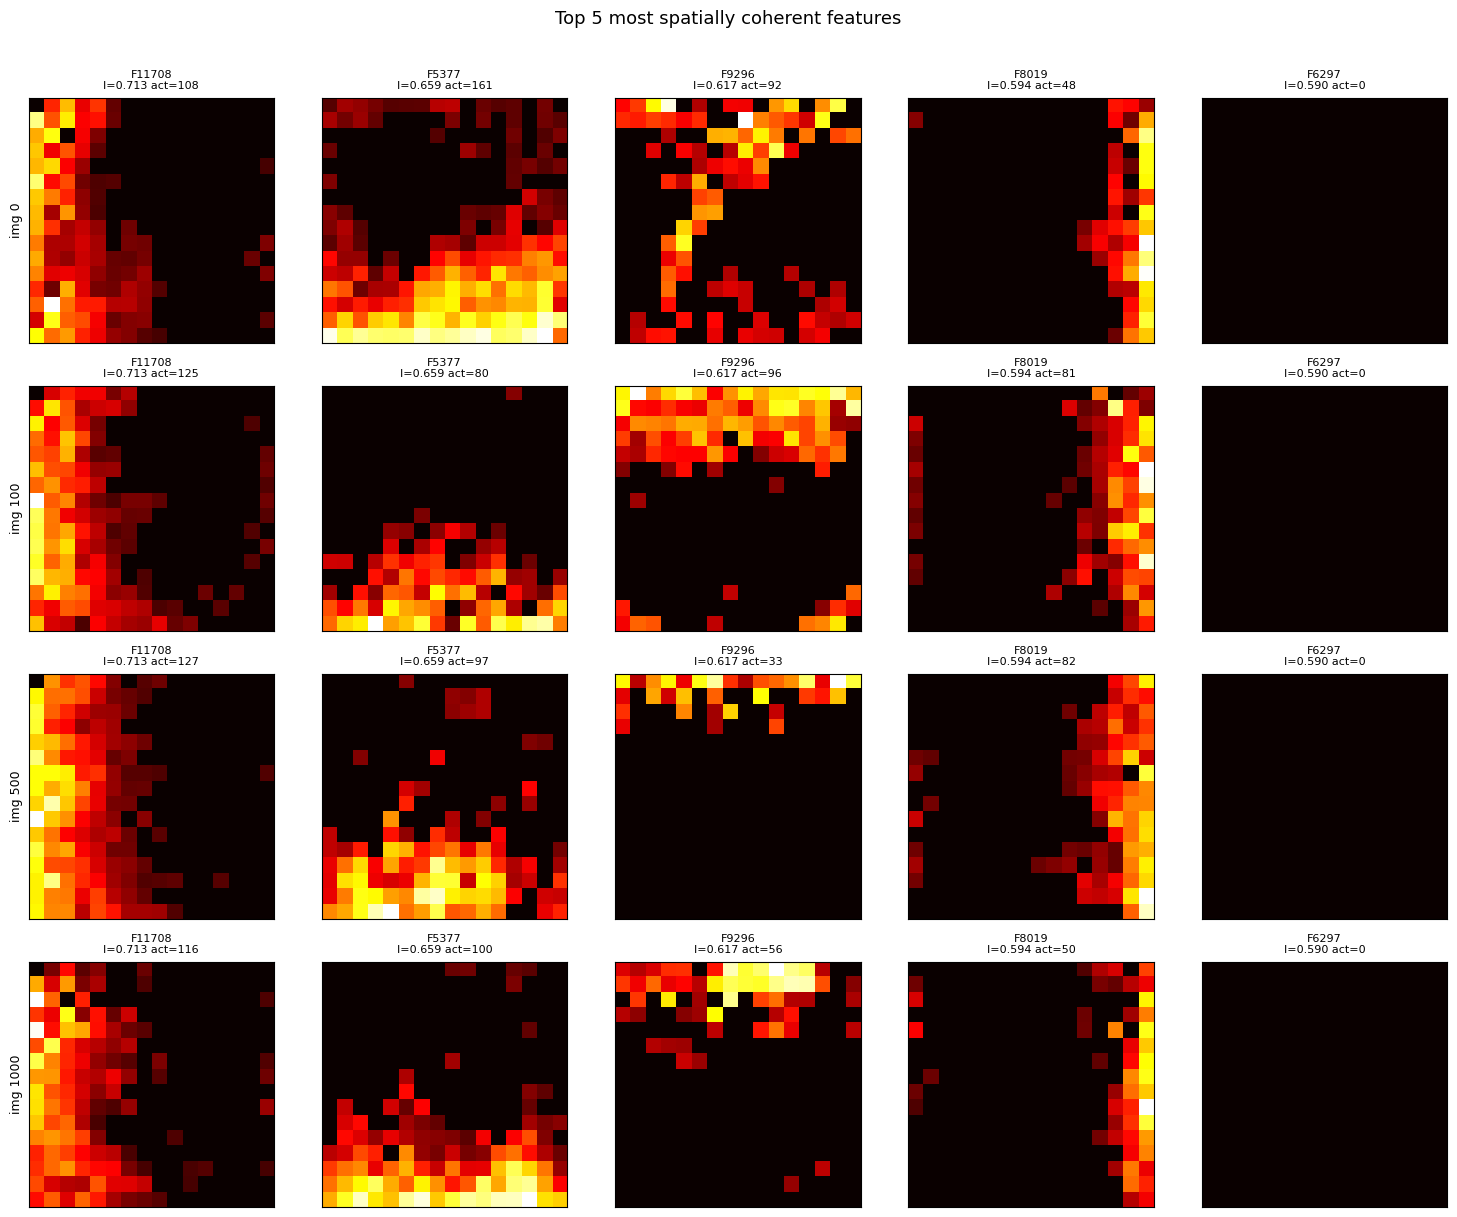

In [15]:
# ── Cell 7: Heatmaps — top 5 most coherent features ─────────────────────────
fig, axes = plt.subplots(len(IMG_INDICES), 5, figsize=(15, 3 * len(IMG_INDICES)))
for row, img_idx in enumerate(IMG_INDICES):
    for col, feat_idx in enumerate(top_feats):
        feat_map = encoded[img_idx][:, feat_idx].reshape(16, 16).numpy()
        ax = axes[row, col]
        ax.imshow(feat_map, cmap="hot", interpolation="nearest")
        active = (feat_map != 0).sum()
        ax.set_title(f"F{feat_idx}\nI={scores_arr[feat_idx]:.3f} act={active}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0: ax.set_ylabel(f"img {img_idx}", fontsize=9)
plt.suptitle("Top 5 most spatially coherent features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

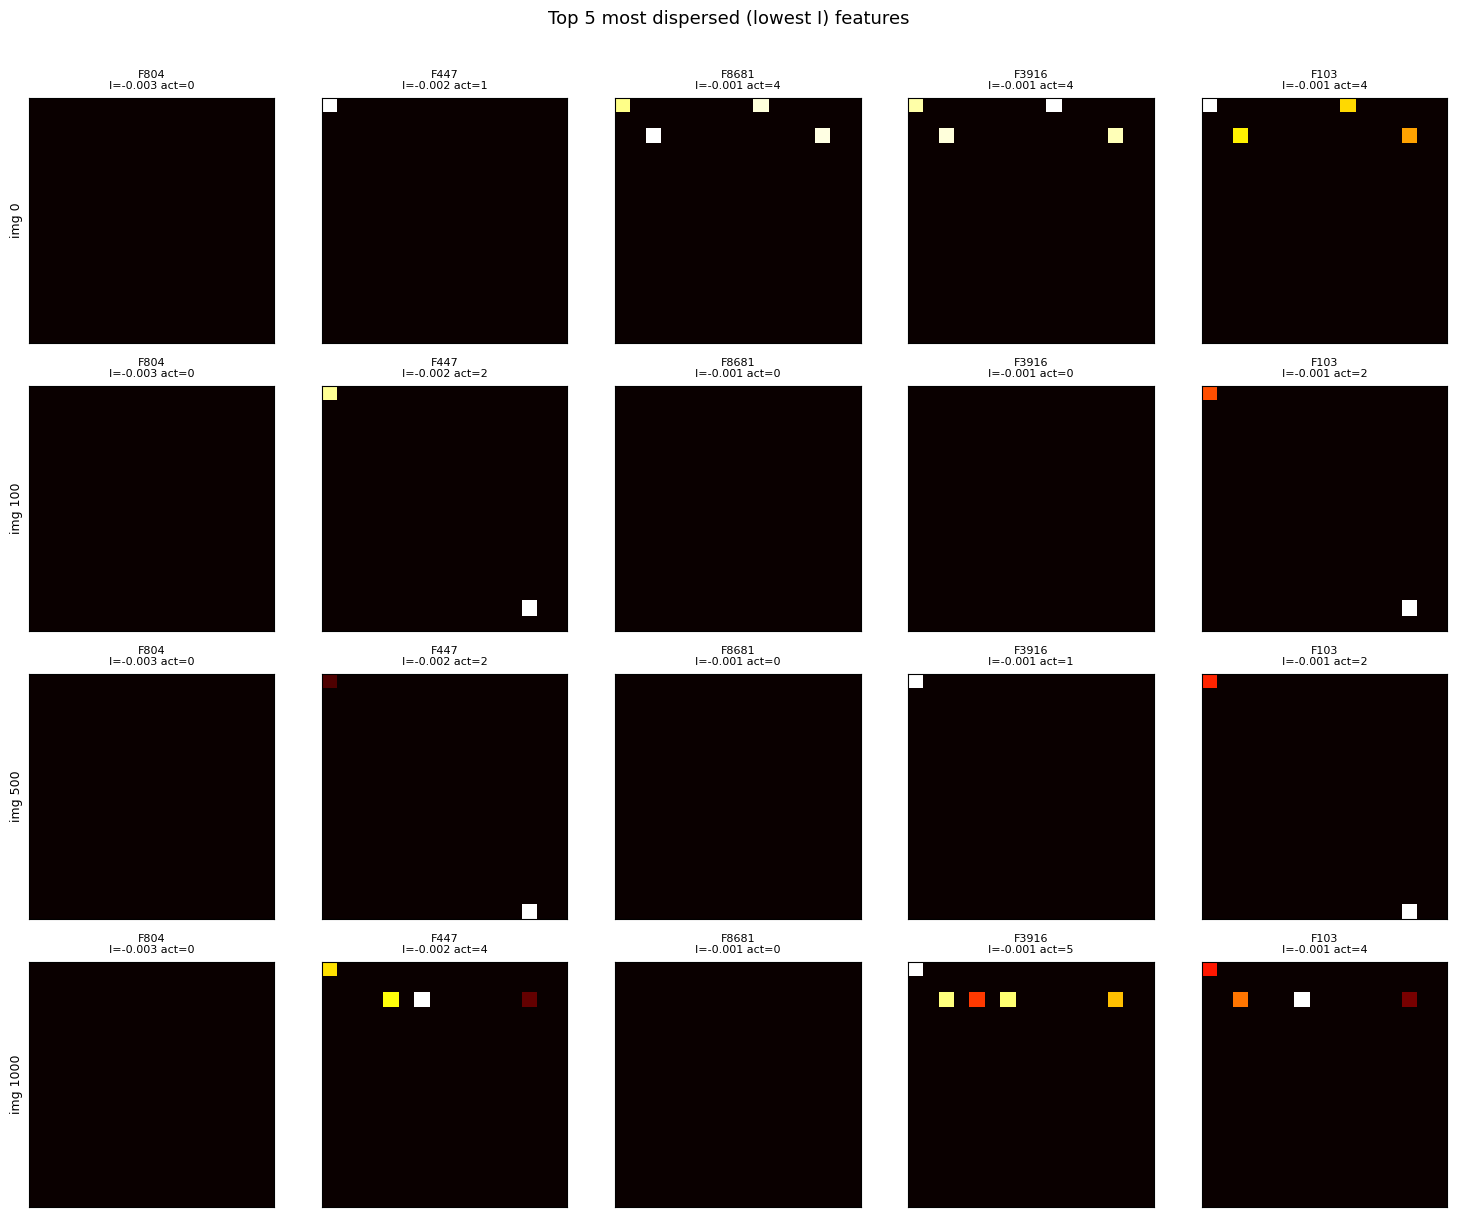

In [16]:
# ── Cell 8: Heatmaps — top 5 most dispersed features ────────────────────────
fig, axes = plt.subplots(len(IMG_INDICES), 5, figsize=(15, 3 * len(IMG_INDICES)))
for row, img_idx in enumerate(IMG_INDICES):
    for col, feat_idx in enumerate(bottom_feats):
        feat_map = encoded[img_idx][:, feat_idx].reshape(16, 16).numpy()
        ax = axes[row, col]
        ax.imshow(feat_map, cmap="hot", interpolation="nearest")
        active = (feat_map != 0).sum()
        ax.set_title(f"F{feat_idx}\nI={scores_arr[feat_idx]:.3f} act={active}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0: ax.set_ylabel(f"img {img_idx}", fontsize=9)
plt.suptitle("Top 5 most dispersed (lowest I) features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

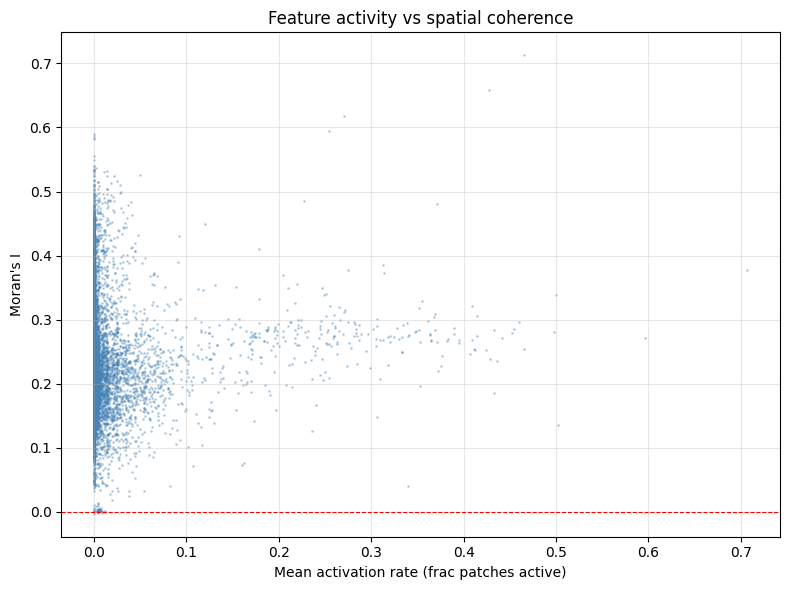

Pearson r (activation rate vs Moran's I): 0.037


In [17]:
# ── Cell 9: Moran's I vs feature activity scatter ────────────────────────────
all_codes = torch.stack([encoded[i] for i in IMG_INDICES])  # [4, 256, dict_size]
mean_act = (all_codes != 0).float().mean(dim=(0, 1)).numpy()
valid_mask = ~np.isnan(scores_arr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mean_act[valid_mask], scores_arr[valid_mask], s=1, alpha=0.3, c="steelblue")
ax.axhline(0, color="red", ls="--", lw=0.8)
ax.set_xlabel("Mean activation rate (frac patches active)")
ax.set_ylabel("Moran's I")
ax.set_title("Feature activity vs spatial coherence")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(mean_act[valid_mask], scores_arr[valid_mask])[0, 1]
print(f"Pearson r (activation rate vs Moran's I): {corr:.3f}")

In [10]:
# ── Cell 10: Cleanup ─────────────────────────────────────────────────────────
del shard, encoded, all_codes
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Done. Change TEST_SHARDS = shard_paths in Cell 4 for the full 50K run.")

Done. Change TEST_SHARDS = shard_paths in Cell 4 for the full 50K run.
